In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [2]:
from kret_notebook import *  # NOTE import first
from kret_lgbm._core.lgbm_nb_imports import *
from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *
from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *
from kret_sklearn._core.sklearn_nb_imports import *
from kret_torch_utils._core.torch_nb_imports import *
from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_lgbm._core.lgbm_nb_imports] Imported kret_lgbm._core.lgbm_nb_imports in 2.4089 seconds
[kret_lightning._core.lightning_nb_imports] Imported kret_lightning._core.lightning_nb_imports in 4.7320 seconds
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 0.3405 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0008 seconds
[kret_optuna._core.optuna_nb_imports] Imported kret_optuna._core.optuna_nb_imports in 0.0010 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.1247 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_sklearn._core.sklearn_nb_imports] Imported kret_sklearn._core.sklearn_nb_imports in 0.4180 seconds
[kret_torch_utils._core.torch_nb_imports] Imported kret_torch_utils._core.torch_nb_imports i

In [3]:
from nba_timeout_impact.load_data_utils import NBADataLoader
from nba_timeout_impact.clean_pipeline import NBAStatsV3CleanPipeline
from nba_timeout_impact.constants import NBAConstants
from nba_timeout_impact.nba_dataset import NBADataset, NBAMemoDF, NBADatasetInput_TypedDict

# Load Data

In [4]:
# NBA_DATA_DIR = NBAConstants.NBA_DATA_DIR
# nba = pd.read_parquet(NBA_DATA_DIR / "nba_statsv3_clean.parquet")
# UKS_NP_PD.dtt([nba], how="head", filter=nba.IsPlayoff)

In [64]:
nba = NBADataset.load_from_parquet()

Validating data...


# Implementation

In [65]:
nba_memo = NBAMemoDF({"data": nba})

In [66]:
gameid = 42400407
f_gameid = nba_memo.data.gameId == gameid

In [67]:
UKS_NP_PD.dtt([nba_memo.data], filter=f_gameid, show_dims=True, n=10, how="head")

,game_date_ffill,gameId,actionId,actionType,subType,scoreHome,scoreAway,pointsTotal,period,teamTricode,shotResult,isFieldGoal,location,description,shotValue,IsPlayoff,seconds_remaining,seconds_elapsed,game_date,playerNameI,actionNumber,clock,teamId,personId,playerName,xLegacy,yLegacy,shotDistance,videoAvailable
,datetime64[ms],int64,int64,category,category,int64,int64,int64,int64,category,category,int64,category,str,float64,bool,float64,float64,datetime64[ms],category,int64,str,int64,int64,category,int64,int64,int64,int64
18049261,2025-06-22,42400407,1,period,start,0,0,0,1,NaN,NaN,0,NaN,Start of 1st Period (8:09 PM EST),0.000,True,720.000,0.000,2025-06-22,NaN,2,PT12M00.00S,0,0,NaN,0,0,0,0
18049262,2025-06-22,42400407,2,Jump Ball,NaN,0,0,0,1,OKC,NaN,0,h,Jump Ball Holmgren vs. Turner: Tip to Haliburton,0.000,True,720.000,0.000,2025-06-22,C. Holmgren,4,PT12M00.00S,1610612760,1631096,Holmgren,0,0,0,1
18049263,2025-06-22,42400407,3,Made Shot,Pullup Jump shot,0,2,2,1,IND,Made,1,v,Nembhard 14' Pullup Jump Shot (2 PTS),2.000,True,704.000,16.000,2025-06-22,A. Nembhard,7,PT11M44.00S,1610612754,1629614,Nembhard,91,106,14,1
18049264,2025-06-22,42400407,4,Missed Shot,Step Back Jump shot,0,2,2,1,OKC,Missed,1,h,MISS Jal. Williams 10' Step Back Jump Shot,2.000,True,689.000,31.000,2025-06-22,J. Williams,8,PT11M29.00S,1610612760,1631114,Williams,-96,22,10,1
18049265,2025-06-22,42400407,5,NaN,NaN,0,2,2,1,IND,NaN,0,v,Nesmith BLOCK (1 BLK),2.000,True,689.000,31.000,2025-06-22,A. Nesmith,8,PT11M29.00S,1610612754,1630174,Nesmith,0,0,0,1
18049266,2025-06-22,42400407,6,Rebound,Unknown,0,2,2,1,IND,NaN,0,v,Nesmith REBOUND (Off:0 Def:1),0.000,True,685.000,35.000,2025-06-22,A. Nesmith,10,PT11M25.00S,1610612754,1630174,Nesmith,0,0,0,1
18049267,2025-06-22,42400407,7,Foul,Personal,0,2,2,1,OKC,NaN,0,h,Dort P.FOUL (P1.T1) (S.Wright),0.000,True,677.000,43.000,2025-06-22,L. Dort,11,PT11M17.00S,1610612760,1629652,Dort,0,0,0,1
18049268,2025-06-22,42400407,8,Missed Shot,Jump Shot,0,2,2,1,IND,Missed,1,v,MISS Turner 24' 3PT Jump Shot,3.000,True,671.000,49.000,2025-06-22,M. Turner,13,PT11M11.00S,1610612754,1626167,Turner,-158,180,24,1
18049269,2025-06-22,42400407,9,Rebound,Unknown,0,2,2,1,OKC,NaN,0,h,Holmgren REBOUND (Off:0 Def:1),0.000,True,668.000,52.000,2025-06-22,C. Holmgren,14,PT11M08.00S,1610612760,1631096,Holmgren,0,0,0,1


In [68]:
UKS_NP_PD.dtt(nba_memo.data, how="tail")

,game_date_ffill,gameId,actionId,actionType,subType,scoreHome,scoreAway,pointsTotal,period,teamTricode,shotResult,isFieldGoal,location,description,shotValue,IsPlayoff,seconds_remaining,seconds_elapsed,game_date,playerNameI,actionNumber,clock,teamId,personId,playerName,xLegacy,yLegacy,shotDistance,videoAvailable
,datetime64[ms],int64,int64,category,category,int64,int64,int64,int64,category,category,int64,category,str,float64,bool,float64,float64,datetime64[ms],category,int64,str,int64,int64,category,int64,int64,int64,int64
18049798,2025-06-22,42400407,538,NaN,NaN,103,89,192,4,IND,NaN,0,v,Mathurin STEAL (2 STL),0.000,True,19.900,700.100,2025-06-22,B. Mathurin,755,PT00M19.90S,1610612754,1631097,Mathurin,0,0,0,1
18049799,2025-06-22,42400407,539,Foul,Shooting,103,89,192,4,OKC,NaN,0,h,Jones S.FOUL (P1.PN) (S.Wright),0.000,True,19.500,700.500,2025-06-22,D. Jones,757,PT00M19.50S,1610612760,1641794,Jones,0,0,0,1
18049800,2025-06-22,42400407,540,Free Throw,Free Throw 1 of 2,103,90,193,4,IND,NaN,0,v,Mathurin Free Throw 1 of 2 (23 PTS),0.000,True,19.500,700.500,2025-06-22,B. Mathurin,759,PT00M19.50S,1610612754,1631097,Mathurin,0,0,0,1
18049801,2025-06-22,42400407,541,Free Throw,Free Throw 2 of 2,103,91,194,4,IND,NaN,0,v,Mathurin Free Throw 2 of 2 (24 PTS),0.000,True,19.500,700.500,2025-06-22,B. Mathurin,760,PT00M19.50S,1610612754,1631097,Mathurin,0,0,0,1
18049802,2025-06-22,42400407,542,period,end,103,91,194,4,NaN,NaN,0,NaN,End of 4th Period (10:49 PM EST),0.000,True,0.000,720.000,2025-06-22,NaN,761,PT00M00.00S,0,0,NaN,0,0,0,1


<Axes: >

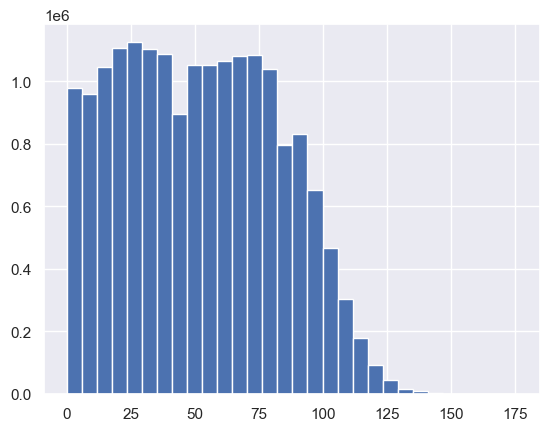

In [69]:
nba_memo.scoreAway.hist(bins=30)

In [11]:
nba_memo.data.columns

Index(['game_date_ffill', 'gameId', 'actionId', 'actionType', 'subType',
       'scoreHome', 'scoreAway', 'pointsTotal', 'period', 'teamTricode',
       'shotResult', 'isFieldGoal', 'location', 'description', 'shotValue',
       'IsPlayoff', 'seconds_remaining', 'seconds_elapsed', 'game_date',
       'playerNameI', 'actionNumber', 'clock', 'teamId', 'personId',
       'playerName', 'xLegacy', 'yLegacy', 'shotDistance', 'videoAvailable'],
      dtype='str')

In [ ]:
def build_streak(df: pd.DataFrame) -> pd.Series:
    game_start = df["gameId"].ne(df["gameId"].shift(fill_value=-1))

    # Zero out at game boundaries — no NaN, no bleed from previous game
    home_pts = df["scoreHome"].diff().clip(lower=0).where(~game_start, 0).fillna(0).astype(int)
    away_pts = df["scoreAway"].diff().clip(lower=0).where(~game_start, 0).fillna(0).astype(int)
    net = home_pts - away_pts

    scorer = UKS_TH_UTILS.assert_type(np.sign(net).replace(0, np.nan), pd.Series).ffill().fillna(0)  # type: ignore

    # game_start acts as a hard reset even if scorer bleeds across boundary
    new_segment = game_start | ((net != 0) & (scorer != scorer.shift(fill_value=0)))
    segment = new_segment.cumsum()

    ret = net.groupby(segment).cumsum()
    ret.name = "streak"
    return ret

In [54]:
out = build_streak(nba_memo.data)

<Axes: >

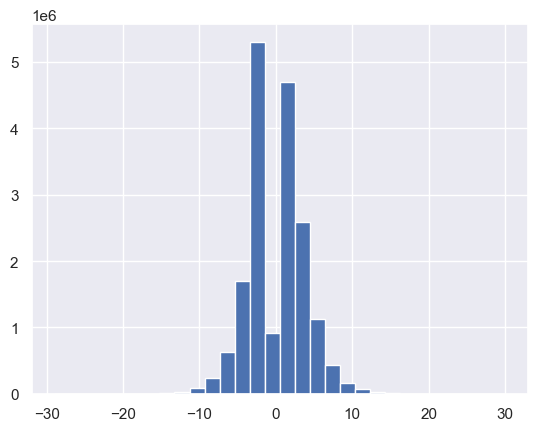

In [55]:
out.hist(bins=30)

# Sandbox

In [56]:
# nba['new_game'] = pd.Categorical(nba.gameId).

In [57]:
nba["lead"] = nba.scoreHome - nba.scoreAway
nba["lead_change"] = nba["lead"].diff()

In [60]:
UKS_TH_UTILS.print_typed_dict_from_callable(UKS_NP_PD.col_filter)

class PD_Convenience_utils_Col_filter_TypedDict(TypedDict, total=False):
    df: DataFrame
    include: list[str] | None  # = []
    exclude: list[str] | None  # = []


{'df': pandas.DataFrame,
 'include': list[str] | None,
 'exclude': list[str] | None,
 'return': pandas.DataFrame}

In [90]:
cols = ["points", "score", "action", "shot", "lead", "streak", "f_", "game"]

In [91]:
nba_memo.f_timeout
nba_memo.streak
_ = nba_memo.f_streak_6, nba_memo.f_streak_9, nba_memo.f_streak_12

In [92]:
UKS_NP_PD.dtt(
    [
        UKS_NP_PD.col_filter(nba, include=cols),
        # nba.col_filter(include=cols),
        # UKS_NP_PD.col_filter(nba_memo.to_pandas(), include=cols),
        nba_memo.to_pandas_memo(),
        out,
    ],
    filter=nba_memo.f_streak_12,
    n=21,
    # how=(50, 70),
    how="head",
    # slice=(0,20),
    show_dims=True,
)

Returning df without 17 columns: ['subType', 'period', 'teamTricode', 'isFieldGoal', 'location', 'description', 'IsPlayoff', 'seconds_remaining', 'seconds_elapsed', 'playerNameI', 'clock', 'teamId', 'personId', 'playerName', 'xLegacy', 'yLegacy', 'videoAvailable']


,game_date_ffill,gameId,actionId,actionType,scoreHome,scoreAway,pointsTotal,shotResult,shotValue,game_date,actionNumber,shotDistance
,datetime64[ms],int64,int64,category,int64,int64,int64,category,float64,datetime64[ms],int64,int64
159,1996-11-01,29600001,160,Made Shot,45,33,78,Made,NaN,1996-11-01,148,0
160,1996-11-01,29600001,161,Foul,45,33,78,NaN,NaN,1996-11-01,149,0
161,1996-11-01,29600001,162,Substitution,45,33,78,NaN,NaN,1996-11-01,151,0
162,1996-11-01,29600001,163,Free Throw,46,33,79,NaN,NaN,1996-11-01,152,0
163,1996-11-01,29600001,164,Missed Shot,46,33,79,Missed,NaN,1996-11-01,153,0
164,1996-11-01,29600001,165,Rebound,46,33,79,NaN,NaN,1996-11-01,154,0
165,1996-11-01,29600001,166,Made Shot,49,33,82,Made,NaN,1996-11-01,155,0
166,1996-11-01,29600001,167,Timeout,49,33,82,NaN,NaN,1996-11-01,156,0
167,1996-11-01,29600001,168,Substitution,49,33,82,NaN,NaN,1996-11-01,158,0
